# Neural Network to Recognise Digits

In [1]:
# importing packages
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
print("import success")

import success


In [2]:
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Split Data

In [3]:
from sklearn.model_selection import train_test_split
print("import success")

import success


In [4]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df.drop(labels=["label"], axis=1), df["label"], test_size = 0.2, random_state = 42
)

X_train = torch.tensor(X_train_raw.values, dtype=torch.float32)
X_test = torch.tensor(X_test_raw.values, dtype=torch.float32)
y_train = torch.tensor(y_train_raw.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_raw.values, dtype=torch.float32).view(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([33600, 784]) torch.Size([33600, 1])
torch.Size([8400, 784]) torch.Size([8400, 1])


## Create Model

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(784, 392)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(392, 196)
        self.layer3 = nn.Linear(196, 98)
        self.layer4 = nn.Linear(98, 50)
        self.output = nn.Linear(50, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.relu(x)
        x = self.layer4(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [6]:
model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [7]:
epochs = 1001

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train.squeeze().long())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if not epoch % 10: 
        print(f'Epoch {epoch}: Loss = {loss.item():.4f}')

Epoch 0: Loss = 2.8800
Epoch 10: Loss = 2.2008
Epoch 20: Loss = 1.9235
Epoch 30: Loss = 1.7032
Epoch 40: Loss = 1.5169
Epoch 50: Loss = 1.3568
Epoch 60: Loss = 1.2199
Epoch 70: Loss = 1.1042
Epoch 80: Loss = 1.0069
Epoch 90: Loss = 0.9254
Epoch 100: Loss = 0.8570
Epoch 110: Loss = 0.7996
Epoch 120: Loss = 0.7511
Epoch 130: Loss = 0.7097
Epoch 140: Loss = 0.6740
Epoch 150: Loss = 0.6429
Epoch 160: Loss = 0.6156
Epoch 170: Loss = 0.5914
Epoch 180: Loss = 0.5696
Epoch 190: Loss = 0.5499
Epoch 200: Loss = 0.5321
Epoch 210: Loss = 0.5159
Epoch 220: Loss = 0.5011
Epoch 230: Loss = 0.4875
Epoch 240: Loss = 0.4750
Epoch 250: Loss = 0.4635
Epoch 260: Loss = 0.4528
Epoch 270: Loss = 0.4429
Epoch 280: Loss = 0.4337
Epoch 290: Loss = 0.4251
Epoch 300: Loss = 0.4171
Epoch 310: Loss = 0.4095
Epoch 320: Loss = 0.4024
Epoch 330: Loss = 0.3956
Epoch 340: Loss = 0.3893
Epoch 350: Loss = 0.3832
Epoch 360: Loss = 0.3775
Epoch 370: Loss = 0.3721
Epoch 380: Loss = 0.3669
Epoch 390: Loss = 0.3620
Epoch 400: 

## Model Evaluation

In [21]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test)  # output is 8400 by 10

    _, predictions = torch.max(test_outputs, dim=1)  # finds the maximum probability in the row (dim=1) then get the label

    pred_np = predictions.detach().cpu().numpy()
    y_test_np = y_test.cpu().detach().numpy().flatten()

print(pred_np.shape)
print(y_test_np.shape)

(8400,)
(8400,)


In [13]:
accuracy = (pred_np == y_test_np).mean()
print(f"Total Accuracy: {accuracy * 100:.2f}%")

Total Accuracy: 92.27%


In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print("import success")

import success


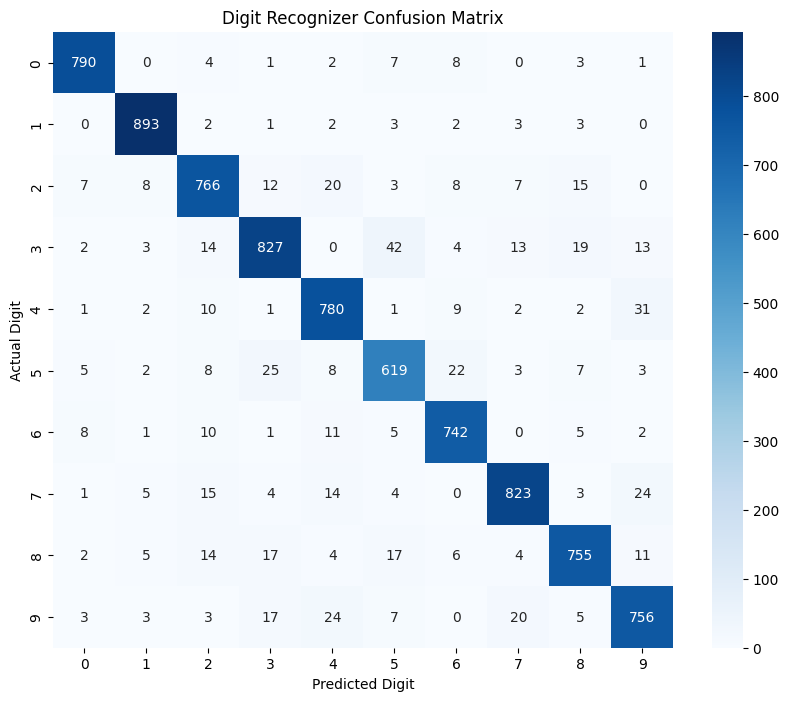

In [15]:
cm = confusion_matrix(y_test_np, pred_np)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.title('Digit Recognizer Confusion Matrix')
plt.show()

In [18]:
print(classification_report(y_test_np, pred_np))

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       816
         1.0       0.97      0.98      0.98       909
         2.0       0.91      0.91      0.91       846
         3.0       0.91      0.88      0.90       937
         4.0       0.90      0.93      0.92       839
         5.0       0.87      0.88      0.88       702
         6.0       0.93      0.95      0.94       785
         7.0       0.94      0.92      0.93       893
         8.0       0.92      0.90      0.91       835
         9.0       0.90      0.90      0.90       838

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400

